In [210]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [211]:
# ================================
# 1. Load and Preprocess Data
# ================================

class Project:
    def __init__(self, type_, name, description):
        self.type = type_
        self.name = name
        self.description = description

def load_projects(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    lines = lines[1:]  # Skip header
    projects = []

    for line in lines:
        parts = line.strip().split("\t")
        if len(parts) > 3:
            projects.append(Project(parts[1], parts[2], parts[3]))

    return projects

file_path = "./Capstone design projects - Raw Data.tsv"
projects = load_projects(file_path)

print(f"Loaded {len(projects)} projects.")
print(f"First project type: {projects[0].type}")
print(f"First project name: {projects[0].name}")
print(f"First project description: {projects[0].description[:100]}...")


Loaded 753 projects.
First project type: Electrical
First project name: Smart load center
First project description: Circuit breaker panels in commercial and residential buildings generally only protect the branch cir...


In [212]:
# Remove from list where decription == "(self explanatory)"
projects = [project for project in projects if project.description != "(self explanatory)"]
print(f"Loaded {len(projects)} projects.")

Loaded 708 projects.


In [213]:
# ================================
# 3. Keyword Extraction per Group using TF-IDF
# ================================
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from collections import defaultdict

# Group descriptions by type
grouped_descriptions = defaultdict(list)
for project in projects:
    grouped_descriptions[project.type].append(project.description)

# Extract keywords per type
print("\nTop Keywords per Project Type:\n")
for type_, descs in grouped_descriptions.items():
    vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
    tfidf = vectorizer.fit_transform(descs)
    scores = np.asarray(tfidf.mean(axis=0)).flatten()
    top_indices = scores.argsort()[-25:][::-1]
    top_keywords = [vectorizer.get_feature_names_out()[i] for i in top_indices]
    print(f"{type_}: {', '.join(top_keywords)}")



Top Keywords per Project Type:

Electrical: data, power, project, time, device, design, sound, sensors, used, allow, water, images, features, control, able, supply, quality, cameras, designed, network, charging, processing, method, bike, monitoring
Mechanical: design, device, project, solution, designed, time, aims, user, water, using, manual, current, 3d, process, cost, waste, use, existing, improve, efficiency, tool, smart, users, heat, automated
System Design: real, device, time, data, speech, feedback, using, app, vision, practice, patients, safety, users, cognitive, designed, wearable, uses, computer, tool, user, alerts, sensors, heat, braille, audio
Nanotechnology: energy, water, blood, solar, design, time, device, health, sustainable, detection, current, solution, disease, using, nanoparticles, providing, monitoring, designed, heat, use, based, effective, real, light, aims
Mechatronics: robot, device, user, designed, solution, time, users, safety, autonomous, real, water, visio

In [214]:
# Grouping Electrical and Computer, Electrical into a group called Electrical
for project in projects:
    if project.type in ["Electrical and Computer", "Electrical"]:
        project.type = "Electrical"

# Grouping Civil, Architectural, Environmental, Geological into a group called CENG
for project in projects:
    if project.type in ["Civil", "Architectural", "Environmental", "Geological"]:
        project.type = "CENG"

# Grouping Biomedical, Chemical, Nanotechnology into a group called BioChem
for project in projects:
    if project.type in ["Biomedical", "Chemical", "Nanotechnology"]:
        project.type = "BioChemNano"

# Grouping Mechatronics and System Design into a group called System
for project in projects:
    if project.type in ["Mechatronics", "System Design", "Management"]:
        project.type = "System"


In [215]:
# ================================
# 3. Keyword Extraction per Group using TF-IDF
# ================================
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from collections import defaultdict

# Group descriptions by type
grouped_descriptions = defaultdict(list)
for project in projects:
    grouped_descriptions[project.type].append(project.description)

# Extract keywords per type
print("\nTop Keywords per Project Type:\n")
for type_, descs in grouped_descriptions.items():
    vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
    tfidf = vectorizer.fit_transform(descs)
    scores = np.asarray(tfidf.mean(axis=0)).flatten()
    top_indices = scores.argsort()[-25:][::-1]
    top_keywords = [vectorizer.get_feature_names_out()[i] for i in top_indices]
    print(f"{type_}: {', '.join(top_keywords)}")



Top Keywords per Project Type:

Electrical: data, users, user, time, project, using, real, power, aims, solution, sensors, experience, app, processing, design, device, learning, smart, designed, information, control, mobile, application, low, safety
Mechanical: design, device, project, solution, designed, time, aims, user, water, using, manual, current, 3d, process, cost, waste, use, existing, improve, efficiency, tool, smart, users, heat, automated
System: time, device, real, users, data, user, designed, solution, robot, students, using, information, feedback, safety, app, aims, vision, process, help, platform, food, computer, uses, water, provide
BioChemNano: water, project, energy, design, aims, process, solution, time, device, sustainable, using, patients, efficiency, current, patient, carbon, waste, heat, used, blood, treatment, approach, detection, plastic, designed
CENG: design, housing, community, building, project, new, water, aims, solution, waterloo, ontario, sustainable, c

In [216]:
# ================================
# 2. Compute Similarity Matrix
# ================================

descriptions = [project.description for project in projects]

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(descriptions)
cosine_sim = cosine_similarity(tfidf_matrix)


Counter({'Electrical': 179, 'System': 173, 'BioChemNano': 149, 'CENG': 120, 'Mechanical': 87})


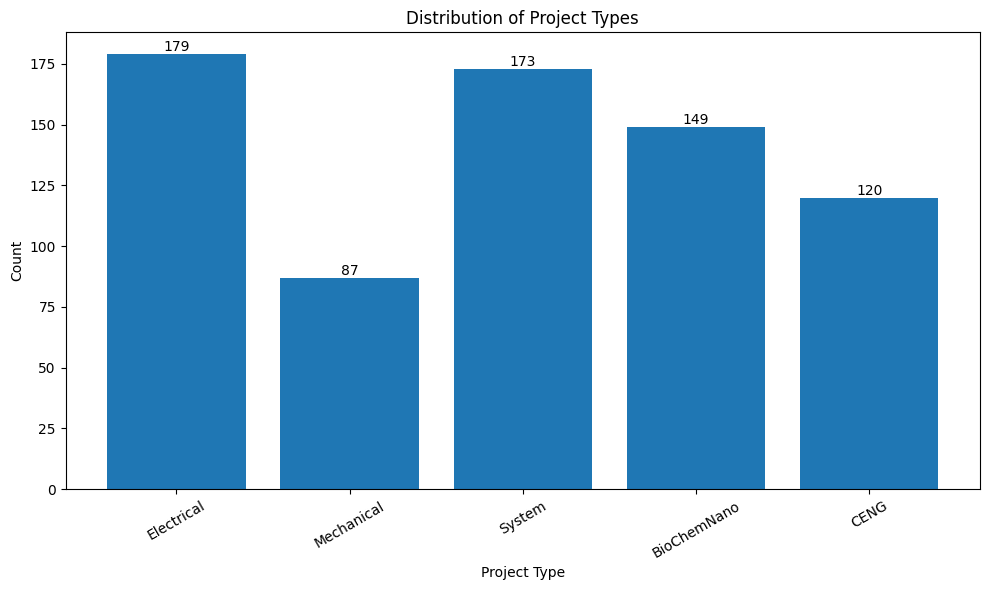

In [217]:
from collections import Counter
type_counts = Counter([p.type for p in projects])
print(type_counts)

# Create a bar chart for counter
plt.figure(figsize=(10, 6))
bars = plt.bar(type_counts.keys(), type_counts.values()) # Store the bar objects
plt.xlabel("Project Type")
plt.ylabel("Count")
plt.title("Distribution of Project Types")
plt.xticks(rotation=30)

# Add labels to the bars
plt.bar_label(bars)

plt.tight_layout()
plt.show()


In [218]:
# ================================
# 3. Compute Average Similarities Between Types
# ================================

project_types = [project.type for project in projects]
unique_types = sorted(set(project_types))
type_indices = {t: i for i, t in enumerate(unique_types)}

n_types = len(unique_types)
avg_similarities = np.zeros((n_types, n_types))
type_counts = np.zeros((n_types, n_types))

for i in range(len(projects)):
    for j in range(len(projects)):
        type_i = type_indices[projects[i].type]
        type_j = type_indices[projects[j].type]
        avg_similarities[type_i, type_j] += cosine_sim[i, j]
        type_counts[type_i, type_j] += 1

# Avoid division by zero
type_counts[type_counts == 0] = 1
avg_similarities /= type_counts


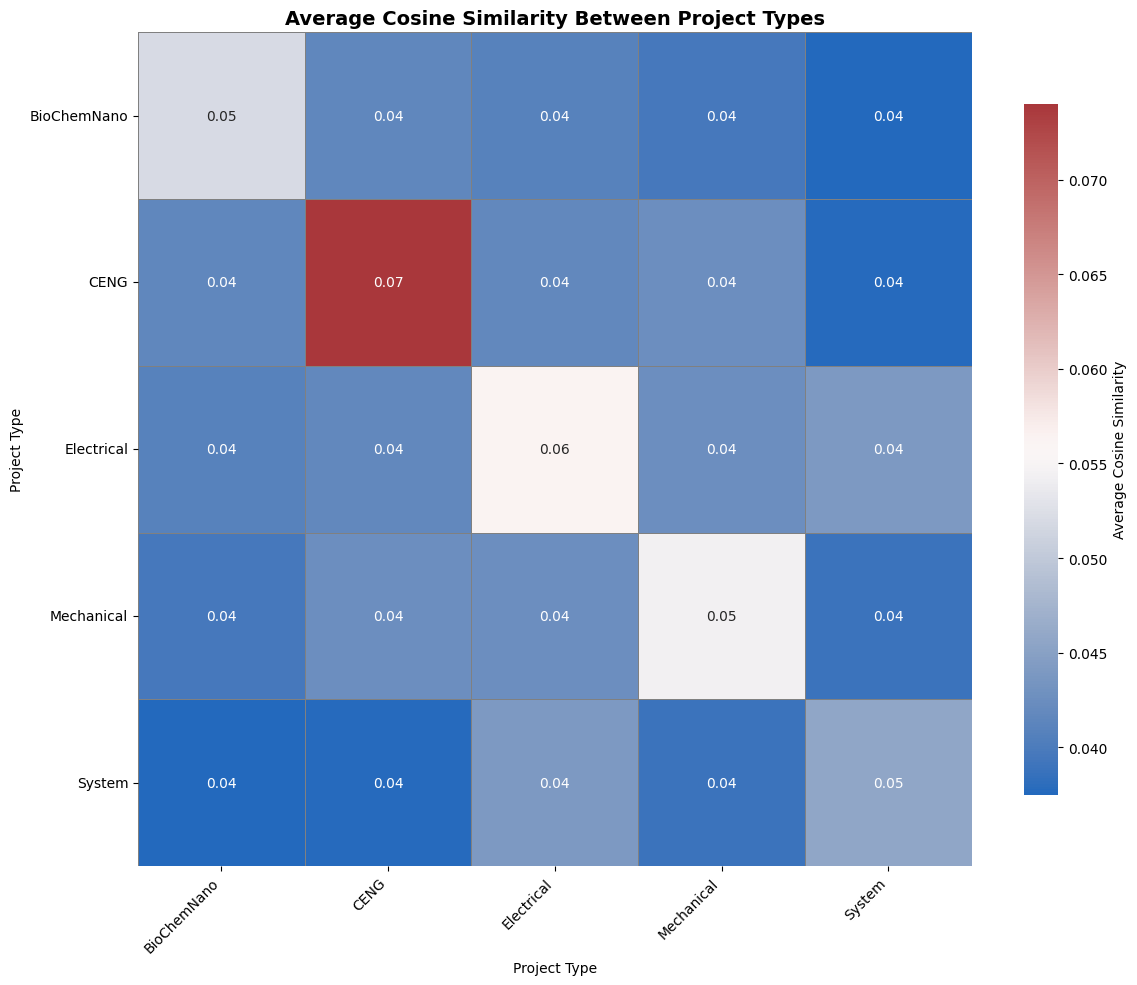

In [219]:
# ================================
# 4. Heatmap Visualization
# ================================

plt.figure(figsize=(12, 10))
sns.heatmap(
    avg_similarities,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    xticklabels=unique_types,
    yticklabels=unique_types,
    linewidths=0.5,
    linecolor="gray",
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Average Cosine Similarity"}
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Average Cosine Similarity Between Project Types", fontsize=14, weight='bold')
plt.xlabel("Project Type")
plt.ylabel("Project Type")
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


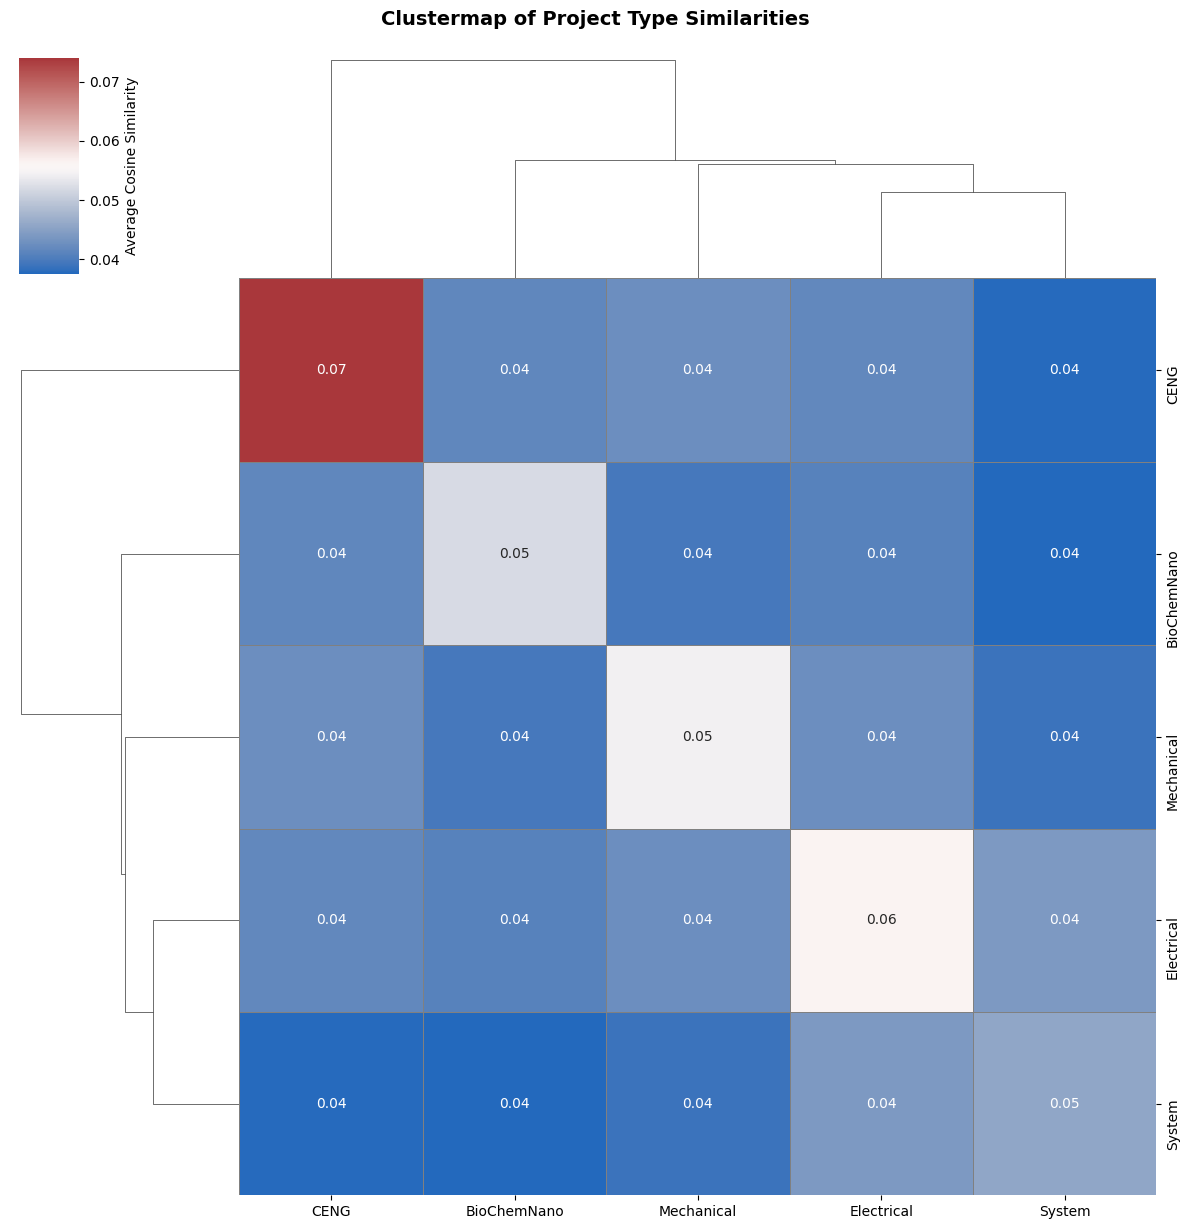

In [220]:
# ================================
# 5. Clustermap Visualization
# ================================

sns.clustermap(
    avg_similarities,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    xticklabels=unique_types,
    yticklabels=unique_types,
    linewidths=0.5,
    linecolor="gray",
    figsize=(12, 12),
    square=True,
    cbar_kws={"label": "Average Cosine Similarity"}
)

plt.suptitle("Clustermap of Project Type Similarities", fontsize=14, weight='bold', y=1.02)
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


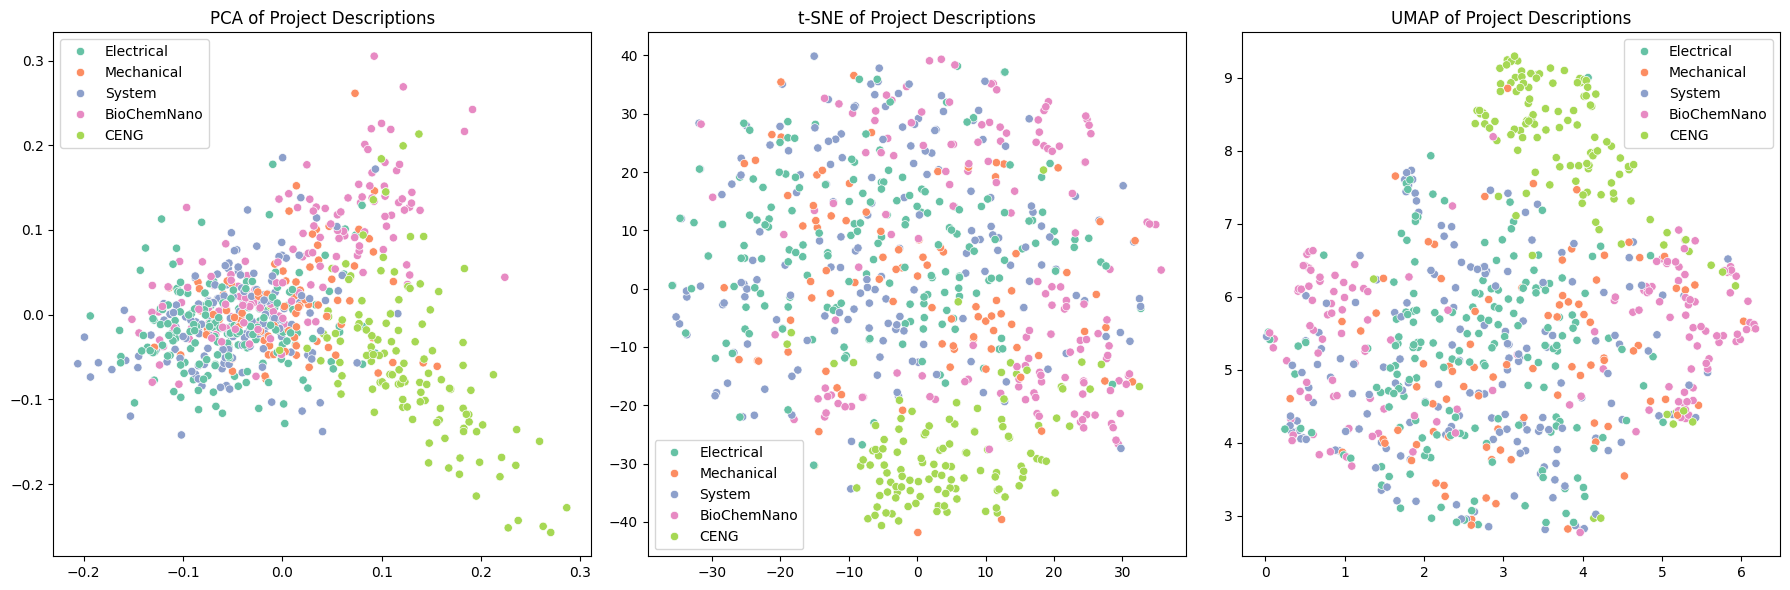

In [221]:
# ================================
# 1. Dimensionality Reduction for Visualization (PCA, t-SNE, UMAP)
# ================================
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

# Use PCA to reduce dimensionality to 2D
pca = PCA(n_components=2)
pca_result = pca.fit_transform(tfidf_matrix.toarray())

# Use t-SNE for non-linear dimensionality reduction
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_result = tsne.fit_transform(tfidf_matrix.toarray())

# Use UMAP for dimensionality reduction
umap_model = umap.UMAP(random_state=42)
umap_result = umap_model.fit_transform(tfidf_matrix.toarray())

# Plot PCA, t-SNE, and UMAP
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

project_labels = [project.type for project in projects]
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=project_labels, ax=axs[0], palette="Set2")
axs[0].set_title("PCA of Project Descriptions")

sns.scatterplot(x=tsne_result[:, 0], y=tsne_result[:, 1], hue=project_labels, ax=axs[1], palette="Set2")
axs[1].set_title("t-SNE of Project Descriptions")

sns.scatterplot(x=umap_result[:, 0], y=umap_result[:, 1], hue=project_labels, ax=axs[2], palette="Set2")
axs[2].set_title("UMAP of Project Descriptions")

plt.tight_layout()
plt.show()

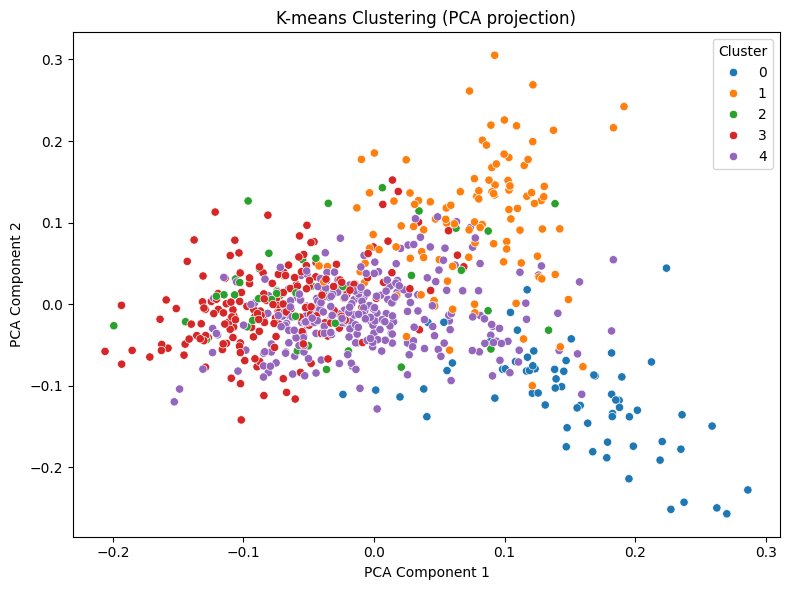


Cluster Counts:
Cluster 4: 289 projects
Cluster 3: 190 projects
Cluster 2: 49 projects
Cluster 1: 113 projects
Cluster 0: 67 projects

Clustering Evaluation Metrics:
Inertia:  667.2193528334869
Silhouette Score:  0.002600874912403369
Homogeneity Score:  0.16144879120669886
Completeness Score:  0.17951337607486417
V-measure Score:  0.17000254194646258
Adjusted Rand Index:  0.09132840351332765
Adjusted Mutual Information:  0.16360283670558415
Davies-Bouldin Index:  11.482846088116228
Calinski-Harabasz Score:  2.599083045663404


In [222]:
# ================================
# 2. K-means Clustering
# ================================
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    homogeneity_score,
    completeness_score,
    adjusted_rand_score,
    adjusted_mutual_info_score,
    v_measure_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Choose a reasonable number of clusters
n_clusters = len(set(project_labels))
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(tfidf_matrix)

# Plot K-means clustering with PCA projection
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=labels, palette="tab10")
plt.title("K-means Clustering (PCA projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

# Evaluation
cluster_counts = Counter(labels)
print("\nCluster Counts:")
for cluster, count in cluster_counts.items():
    print(f"Cluster {cluster}: {count} projects")

print("\nClustering Evaluation Metrics:")
print("Inertia: ", kmeans.inertia_)
print("Silhouette Score: ", silhouette_score(tfidf_matrix, labels))
print("Homogeneity Score: ", homogeneity_score(project_labels, labels))
print("Completeness Score: ", completeness_score(project_labels, labels))
print("V-measure Score: ", v_measure_score(project_labels, labels))
print("Adjusted Rand Index: ", adjusted_rand_score(project_labels, labels))
print("Adjusted Mutual Information: ", adjusted_mutual_info_score(project_labels, labels))
print("Davies-Bouldin Index: ", davies_bouldin_score(tfidf_matrix.toarray(), labels))
print("Calinski-Harabasz Score: ", calinski_harabasz_score(tfidf_matrix.toarray(), labels))


In [223]:
# ================================
# 4. Intra-Group vs Inter-Group Similarity Analysis
# ================================

intra_group_sim = {}
inter_group_sim = {}

for i, type_i in enumerate(unique_types):
    for j, type_j in enumerate(unique_types):
        sim = avg_similarities[i][j]
        key = f"{type_i} vs {type_j}"
        if type_i == type_j:
            intra_group_sim[type_i] = sim
        else:
            inter_group_sim[key] = sim

print("\nIntra-Group Similarities:")
for k, v in intra_group_sim.items():
    print(f"{k}: {v:.3f}")

print("\nAll Inter-Group Similarities:")
top_inter = sorted(inter_group_sim.items(), key=lambda x: x[1], reverse=True)
for k, v in top_inter:
    print(f"{k}: {v:.3f}")



Intra-Group Similarities:
BioChemNano: 0.052
CENG: 0.074
Electrical: 0.056
Mechanical: 0.054
System: 0.046

All Inter-Group Similarities:
Electrical vs System: 0.044
System vs Electrical: 0.044
CENG vs Mechanical: 0.043
Mechanical vs CENG: 0.043
Electrical vs Mechanical: 0.043
Mechanical vs Electrical: 0.043
CENG vs Electrical: 0.042
Electrical vs CENG: 0.042
CENG vs BioChemNano: 0.041
BioChemNano vs CENG: 0.041
BioChemNano vs Electrical: 0.041
Electrical vs BioChemNano: 0.041
Mechanical vs BioChemNano: 0.040
BioChemNano vs Mechanical: 0.040
Mechanical vs System: 0.039
System vs Mechanical: 0.039
CENG vs System: 0.038
System vs CENG: 0.038
System vs BioChemNano: 0.038
BioChemNano vs System: 0.038
